# ⚖️ Paso 5 — Comparación KNN vs Decision Tree
**Dataset:** Consumo eléctrico industrial
**Objetivo:** Comparar ambos modelos con métricas, gráficas y conclusiones

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import os
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, ConfusionMatrixDisplay,
                              precision_score, recall_score, f1_score,
                              roc_curve, auc)
from sklearn.preprocessing import label_binarize
from sklearn.model_selection import cross_val_score, StratifiedKFold

os.makedirs('outputs/figures', exist_ok=True)
os.makedirs('outputs/results', exist_ok=True)
sns.set_theme(style='whitegrid')
CLASES = ['Light_Load', 'Maximum_Load', 'Medium_Load']
print('✅ Librerías cargadas')

✅ Librerías cargadas


## 1. Cargar datos y resultados previos

In [2]:
X_train = pd.read_csv('data/processed/X_train.csv')
X_test  = pd.read_csv('data/processed/X_test.csv')
y_train = pd.read_csv('data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('data/processed/y_test.csv').squeeze()

res_knn = pd.read_csv('outputs/results/resultados_knn.csv')
res_dt  = pd.read_csv('outputs/results/resultados_dt.csv')

mejor_k     = int(res_knn['Mejor_K'].values[0])
mejor_depth = int(res_dt['Mejor_depth'].values[0])

print(f'Mejor K (KNN):              {mejor_k}')
print(f'Mejor profundidad (D. Tree): {mejor_depth}')
print('✅ Datos cargados')

Mejor K (KNN):              1
Mejor profundidad (D. Tree): 13
✅ Datos cargados


## 2. Re-entrenar ambos modelos

In [3]:
knn = KNeighborsClassifier(n_neighbors=mejor_k)
knn.fit(X_train, y_train)
y_pred_knn = knn.predict(X_test)

dt = DecisionTreeClassifier(max_depth=mejor_depth, criterion='gini', random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)

print('✅ Modelos entrenados')

✅ Modelos entrenados


## 3. Tabla comparativa de métricas

In [4]:
def calcular_metricas(nombre, y_true, y_pred):
    return {
        'Modelo':    nombre,
        'Accuracy':  round(accuracy_score(y_true, y_pred), 4),
        'Precision': round(precision_score(y_true, y_pred, average='weighted'), 4),
        'Recall':    round(recall_score(y_true, y_pred, average='weighted'), 4),
        'F1_Score':  round(f1_score(y_true, y_pred, average='weighted'), 4)
    }

tabla = pd.DataFrame([
    calcular_metricas('KNN',           y_test, y_pred_knn),
    calcular_metricas('Decision Tree', y_test, y_pred_dt)
])

tabla.set_index('Modelo', inplace=True)
tabla.to_csv('outputs/results/comparacion_final.csv')
print('=== TABLA COMPARATIVA ===')
print(tabla.to_string())

ganador = tabla['F1_Score'].idxmax()
print(f'\n🏆 Mejor modelo por F1_Score: {ganador}')

=== TABLA COMPARATIVA ===
               Accuracy  Precision  Recall  F1_Score
Modelo                                              
KNN              0.8587     0.8589  0.8587    0.8588
Decision Tree    0.8982     0.8982  0.8982    0.8982

🏆 Mejor modelo por F1_Score: Decision Tree


## 4. Gráfica de barras — Comparación de métricas

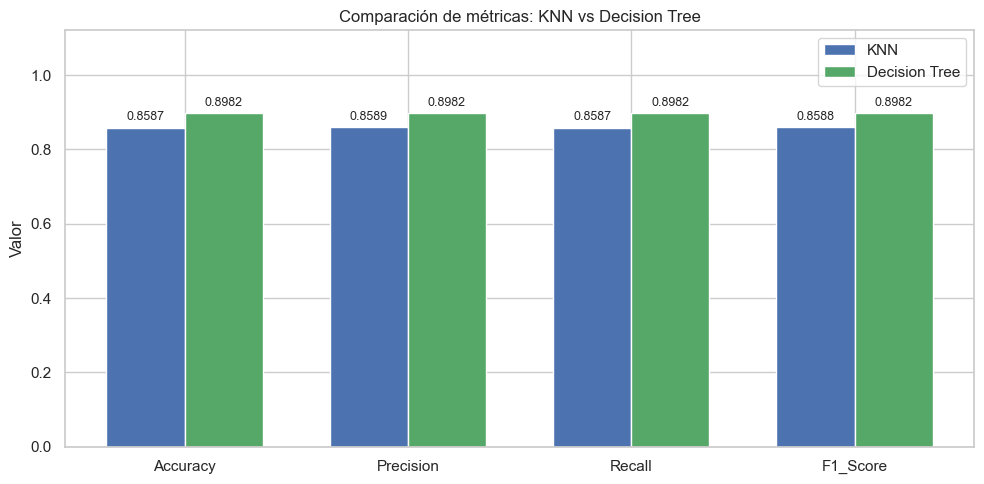

In [5]:
metricas = ['Accuracy', 'Precision', 'Recall', 'F1_Score']
x = np.arange(len(metricas))
ancho = 0.35

fig, ax = plt.subplots(figsize=(10, 5))
barras_knn = ax.bar(x - ancho/2, tabla.loc['KNN', metricas],           ancho, label='KNN',           color='#4C72B0', edgecolor='white')
barras_dt  = ax.bar(x + ancho/2, tabla.loc['Decision Tree', metricas], ancho, label='Decision Tree', color='#55A868', edgecolor='white')

ax.bar_label(barras_knn, fmt='%.4f', padding=3, fontsize=9)
ax.bar_label(barras_dt,  fmt='%.4f', padding=3, fontsize=9)

ax.set_title('Comparación de métricas: KNN vs Decision Tree')
ax.set_ylabel('Valor')
ax.set_xticks(x)
ax.set_xticklabels(metricas)
ax.set_ylim(0, 1.12)
ax.legend()
plt.tight_layout()
plt.savefig('outputs/figures/comparacion_metricas.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Matrices de confusión — lado a lado

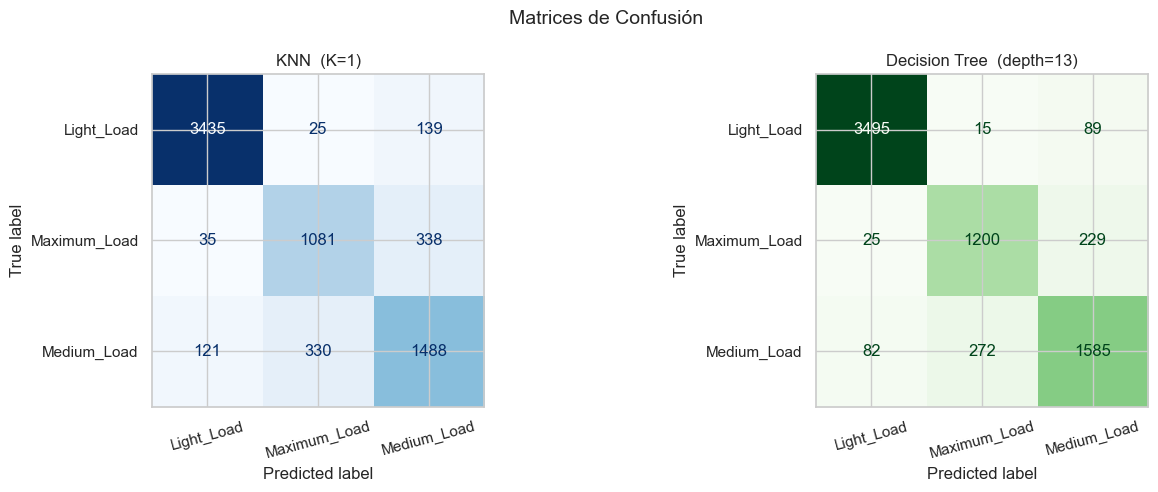

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_knn = confusion_matrix(y_test, y_pred_knn)
ConfusionMatrixDisplay(cm_knn, display_labels=CLASES).plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'KNN  (K={mejor_k})')
axes[0].tick_params(axis='x', rotation=15)

cm_dt = confusion_matrix(y_test, y_pred_dt)
ConfusionMatrixDisplay(cm_dt, display_labels=CLASES).plot(ax=axes[1], colorbar=False, cmap='Greens')
axes[1].set_title(f'Decision Tree  (depth={mejor_depth})')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('Matrices de Confusión', fontsize=14)
plt.tight_layout()
plt.savefig('outputs/figures/comparacion_confusion.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Validación cruzada — distribución de accuracy

KNN           — Media: 0.8526 | Std: 0.0043
Decision Tree — Media: 0.8968  | Std: 0.0046


C:\Users\ACER\AppData\Local\Temp\ipykernel_32168\2817110172.py:10: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot([scores_knn, scores_dt], labels=['KNN', 'Decision Tree'],


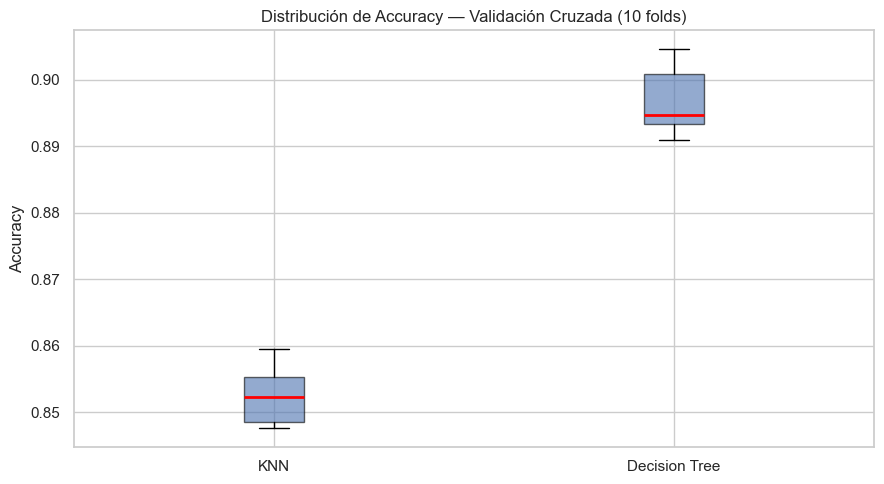

In [7]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

scores_knn = cross_val_score(knn, X_train, y_train, cv=cv, scoring='accuracy')
scores_dt  = cross_val_score(dt,  X_train, y_train, cv=cv, scoring='accuracy')

print(f'KNN           — Media: {scores_knn.mean():.4f} | Std: {scores_knn.std():.4f}')
print(f'Decision Tree — Media: {scores_dt.mean():.4f}  | Std: {scores_dt.std():.4f}')

fig, ax = plt.subplots(figsize=(9, 5))
ax.boxplot([scores_knn, scores_dt], labels=['KNN', 'Decision Tree'],
           patch_artist=True,
           boxprops=dict(facecolor='#4C72B0', alpha=0.6),
           medianprops=dict(color='red', linewidth=2))
ax.set_title('Distribución de Accuracy — Validación Cruzada (10 folds)')
ax.set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('outputs/figures/comparacion_cv_boxplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Curvas ROC por clase

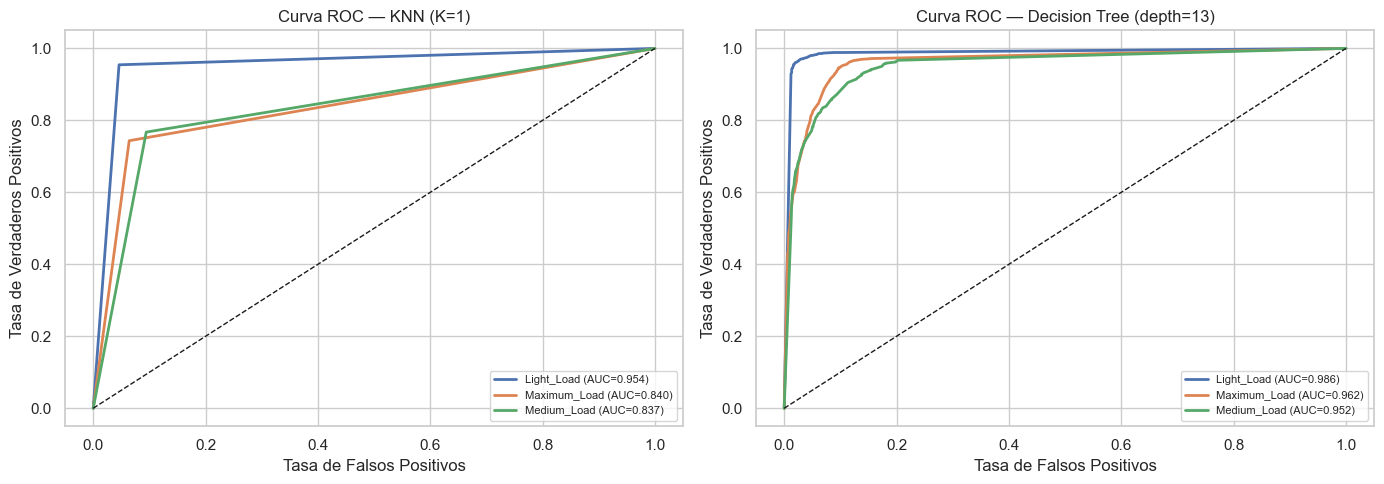

In [8]:
y_test_bin    = label_binarize(y_test, classes=[0, 1, 2])
y_prob_knn    = knn.predict_proba(X_test)
y_prob_dt     = dt.predict_proba(X_test)
colores_clases = ['#4C72B0', '#DD8452', '#55A868']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for i, (clase, color) in enumerate(zip(CLASES, colores_clases)):
    # KNN
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_knn[:, i])
    auc_val = auc(fpr, tpr)
    axes[0].plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC={auc_val:.3f})')

    # Decision Tree
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_prob_dt[:, i])
    auc_val = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color=color, lw=2, label=f'{clase} (AUC={auc_val:.3f})')

for ax, titulo in zip(axes, [f'Curva ROC — KNN (K={mejor_k})', f'Curva ROC — Decision Tree (depth={mejor_depth})']):
    ax.plot([0,1],[0,1], 'k--', lw=1)
    ax.set_title(titulo)
    ax.set_xlabel('Tasa de Falsos Positivos')
    ax.set_ylabel('Tasa de Verdaderos Positivos')
    ax.legend(loc='lower right', fontsize=8)

plt.tight_layout()
plt.savefig('outputs/figures/comparacion_roc.png', dpi=150, bbox_inches='tight')
plt.show()

## ✅ 8. Conclusiones del experimento

In [9]:
acc_knn = tabla.loc['KNN', 'Accuracy']
acc_dt  = tabla.loc['Decision Tree', 'Accuracy']
f1_knn  = tabla.loc['KNN', 'F1_Score']
f1_dt   = tabla.loc['Decision Tree', 'F1_Score']
ganador = 'KNN' if f1_knn > f1_dt else 'Decision Tree'
diferencia = abs(f1_knn - f1_dt)

print('=' * 60)
print('CONCLUSIONES DEL EXPERIMENTO')
print('=' * 60)
print(f'Problema:        Clasificación de consumo eléctrico industrial')
print(f'Clases:          Light_Load, Medium_Load, Maximum_Load')
print(f'')
print(f'KNN (K={mejor_k}):')
print(f'  Accuracy:  {acc_knn:.4f}')
print(f'  F1_Score:  {f1_knn:.4f}')
print(f'  CV Media:  {scores_knn.mean():.4f} ± {scores_knn.std():.4f}')
print(f'')
print(f'Decision Tree (depth={mejor_depth}):')
print(f'  Accuracy:  {acc_dt:.4f}')
print(f'  F1_Score:  {f1_dt:.4f}')
print(f'  CV Media:  {scores_dt.mean():.4f} ± {scores_dt.std():.4f}')
print(f'')
print(f'🏆 Mejor modelo: {ganador}')
print(f'   Diferencia en F1: {diferencia:.4f}')
print('=' * 60)
print('\nVentajas de KNN:')
print('  · Simple de implementar y entender')
print('  · No requiere entrenamiento explícito')
print('  · Funciona bien con clases bien separadas')
print('\nVentajas de Decision Tree:')
print('  · Interpretable: se puede visualizar el árbol')
print('  · Muestra la importancia de cada variable')
print('  · Más rápido en predicción')
print('  · No requiere normalización de datos')
print('=' * 60)
print('✅ Experimento completado')

CONCLUSIONES DEL EXPERIMENTO
Problema:        Clasificación de consumo eléctrico industrial
Clases:          Light_Load, Medium_Load, Maximum_Load

KNN (K=1):
  Accuracy:  0.8587
  F1_Score:  0.8588
  CV Media:  0.8526 ± 0.0043

Decision Tree (depth=13):
  Accuracy:  0.8982
  F1_Score:  0.8982
  CV Media:  0.8968 ± 0.0046

🏆 Mejor modelo: Decision Tree
   Diferencia en F1: 0.0394

Ventajas de KNN:
  · Simple de implementar y entender
  · No requiere entrenamiento explícito
  · Funciona bien con clases bien separadas

Ventajas de Decision Tree:
  · Interpretable: se puede visualizar el árbol
  · Muestra la importancia de cada variable
  · Más rápido en predicción
  · No requiere normalización de datos
✅ Experimento completado
